# XAI (Explainable AI)

## load needed artifacts

### construct the model architecture

In [1]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.15):
        super().__init__()
        self.block=nn.Sequential(
            nn.BatchNorm1d(in_dim),
            nn.SiLU(),
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim)
        )
        self.shourtcut = (
            nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        )
    def forward(self, x):
        return self.block(x) + self.shourtcut(x)
    
class ResidualModel(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.input= nn.Linear(in_dim, 256)
        self.blocks = nn.Sequential(
            ResidualBlock(256, 256),
            ResidualBlock(256, 128),
            ResidualBlock(128, 128)
        )
        self.head = nn.Sequential(
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.input(x)
        x = self.blocks(x)
        return self.head(x)

### import the model configuration 

In [2]:
import json
with open("artifacts/model_config.json") as f:
    config = json.load(f)

input_dim = config["input_dim"]
feat_col = config["feature_cols"]
num_classes = config['num_classes']
classes_names = config['classes']

### load input scaler

In [3]:
import joblib
scaler = joblib.load("artifacts\scaler.pkl")

### load the model

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResidualModel(input_dim, num_classes).to(device)

# load the weights
model.load_state_dict(torch.load("artifacts/best_model.pth", weights_only=True, map_location=device))

model.eval() #to be ready for prediction not training

ResidualModel(
  (input): Linear(in_features=182, out_features=256, bias=True)
  (blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): SiLU()
        (2): Linear(in_features=256, out_features=256, bias=True)
        (3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): SiLU()
        (5): Dropout(p=0.15, inplace=False)
        (6): Linear(in_features=256, out_features=256, bias=True)
      )
      (shourtcut): Identity()
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): SiLU()
        (2): Linear(in_features=256, out_features=128, bias=True)
        (3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): SiLU()
        (5): Dropout(p=0.15, inplace=False)
        (

### load data

In [5]:
import pandas as pd
val_data = pd.read_parquet("data/processed/validation_data.parquet")

## data preprocessing

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
val_data["label"] = le.fit_transform(val_data["IncidentGrade"])

In [7]:
import numpy as np
X_val = val_data[feat_col].values.astype(np.float32)
y_val = val_data["label"]

In [8]:
# scale the data
X_val_scaled = scaler.transform(X_val)

In [9]:
# create two samples one for the background(baseline) and one for explaination
sample_per_class = 500
np.random.seed(67)

backg_idx = []
exp_idx = []

for cls in range(num_classes):
    class_mask = np.where(y_val == cls)[0]
    chosen_samples = np.random.choice(class_mask, sample_per_class * 2, replace=False)
    backg_idx.extend(chosen_samples[:sample_per_class])
    exp_idx.extend(chosen_samples[sample_per_class:])

X_background = X_val_scaled[backg_idx]
X_explain = X_val_scaled[exp_idx]
y_explain = y_val[exp_idx]

X_background_tensor = torch.tensor(X_background, dtype=torch.float32).to(device)
X_explain_tensor = torch.tensor(X_explain, dtype=torch.float32).to(device)

np.save('artifacts/shap_background.npy', X_background)
print(f'Background: {X_background_tensor.shape}')
print(f'Explain: {X_explain_tensor.shape}')
print(f'Class counts in explain set: {dict(zip(classes_names, np.bincount(y_explain)))}')

Background: torch.Size([1500, 182])
Explain: torch.Size([1500, 182])
Class counts in explain set: {'BenignPositive': np.int64(500), 'FalsePositive': np.int64(500), 'TruePositive': np.int64(500)}


## compute the shap values

In [10]:
import shap

explainer = shap.GradientExplainer(model, X_background_tensor)

shap_values = explainer.shap_values(X_explain_tensor)
shap_values = np.stack(shap_values, axis=-1)

np.save('artifacts/shap_values.npy', shap_values)

## explain the model

### global feature importance

In [11]:
# get the average importance of each feature
global_importance = np.abs(shap_values).mean(axis=(1,2))

importance_df = pd.DataFrame({
    "feature" : feat_col,
    "importance" : global_importance
}).sort_values("importance", ascending=False).reset_index(drop=True)

# save importance data
importance_df.to_csv('artifacts/feature_importance.csv', index=False)

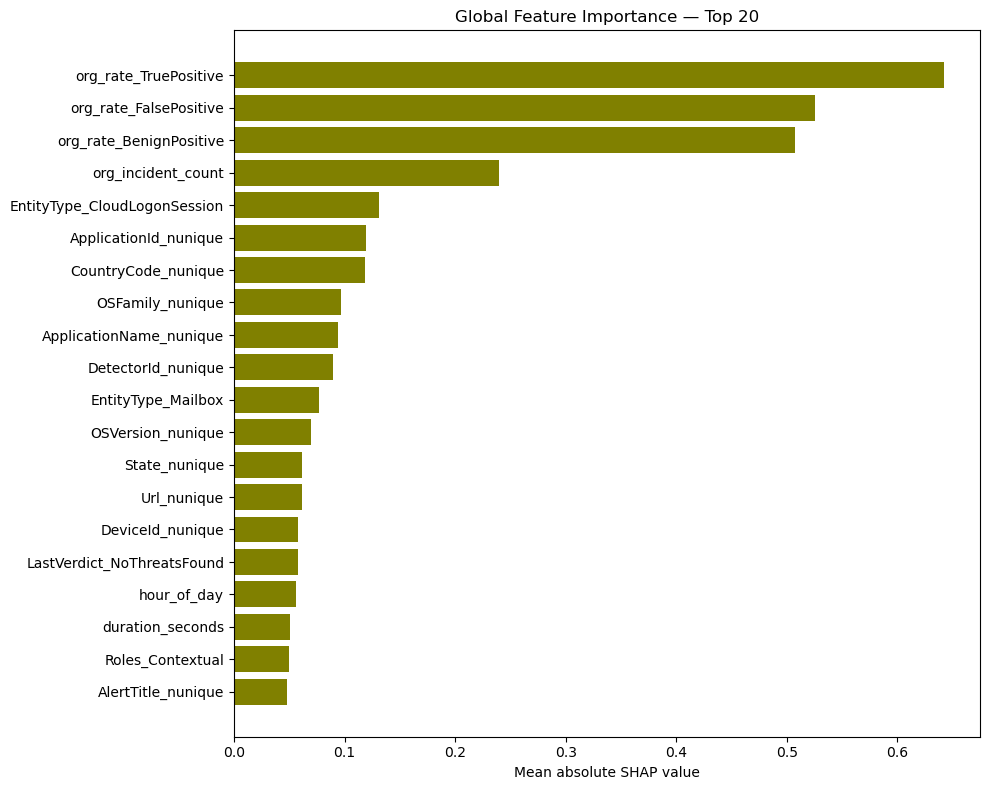

In [12]:
import matplotlib.pyplot as plt
top_feat = 20

top = importance_df.head(top_feat)
fig, ax = plt.subplots(figsize = (10,8))
ax.barh(top["feature"][::-1], top["importance"][::-1], color="olive")
ax.set_xlabel('Mean absolute SHAP value')
ax.set_title(f'Global Feature Importance — Top {top_feat}')
plt.tight_layout()
plt.savefig('artifacts/xai_global_importance.png', dpi=150)
plt.show()

### per class feature importance

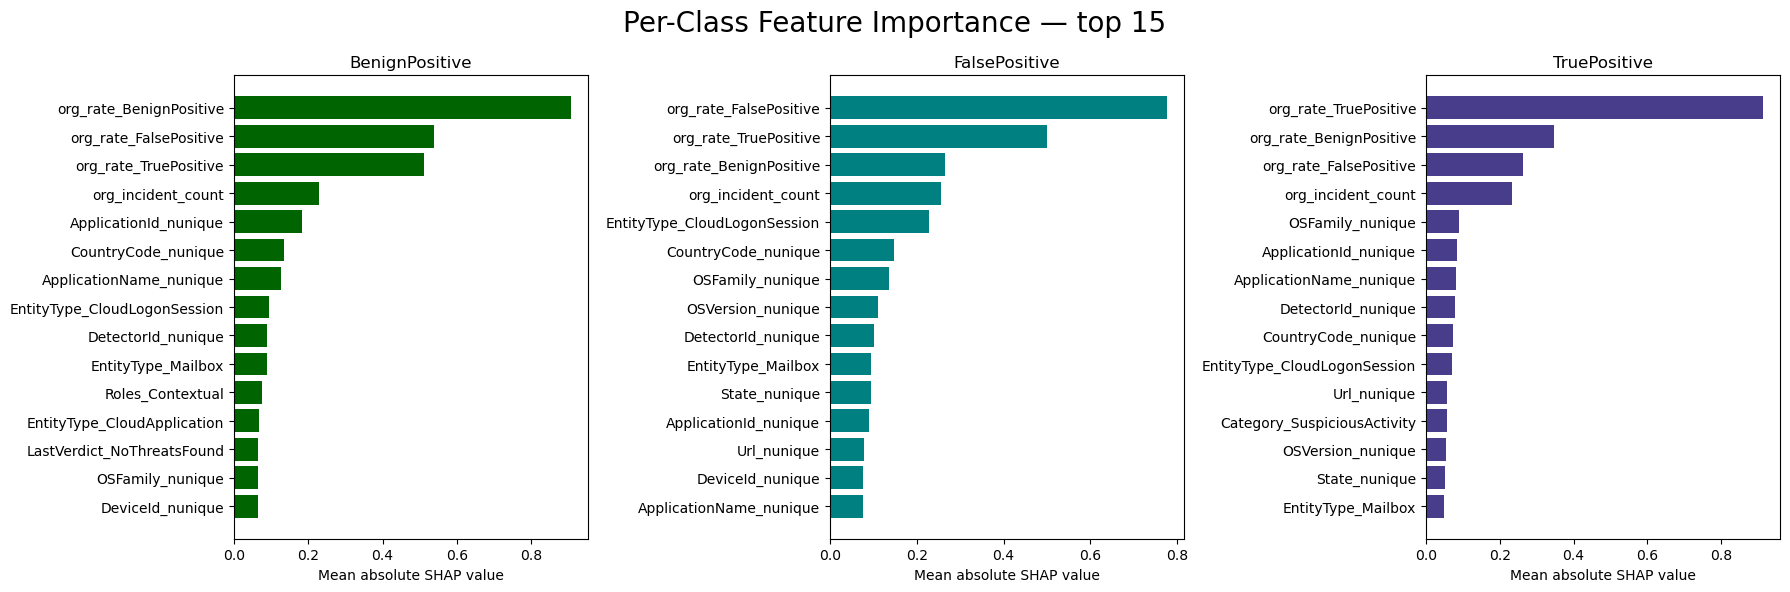

In [13]:
per_class_importance = np.abs(shap_values).mean(axis=(2))

top_feat = 15
colors = ["darkgreen", "teal", "darkslateblue"]

fig, axs = plt.subplots(1,3, figsize = (18,6))

for cls, (cls_name, color, ax) in enumerate(zip(classes_names, colors, axs)):
    class_importance = pd.Series(per_class_importance[:,cls], index = feat_col)
    class_importance = class_importance.sort_values(ascending=False).head(top_feat)
    ax.barh(class_importance.index[::-1], class_importance.values[::-1], color = color)
    ax.set_title(cls_name)
    ax.set_xlabel('Mean absolute SHAP value')

plt.suptitle(f'Per-Class Feature Importance — top {top_feat}', fontsize=20)
plt.tight_layout()
plt.savefig('artifacts/xai_per_class_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### beeswarm blot per class

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17272\3847629345.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


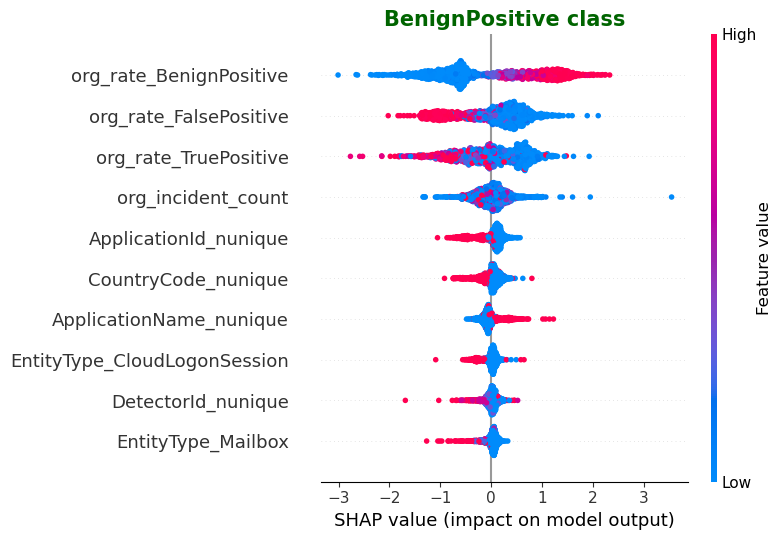

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17272\3847629345.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


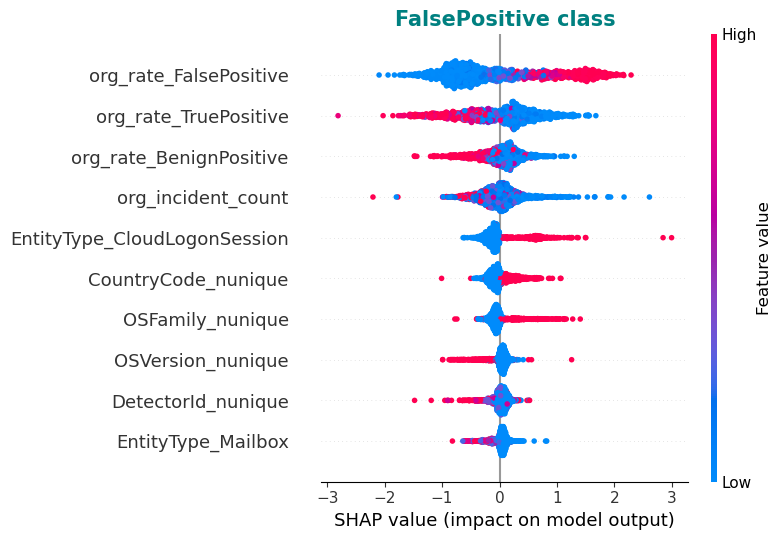

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17272\3847629345.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


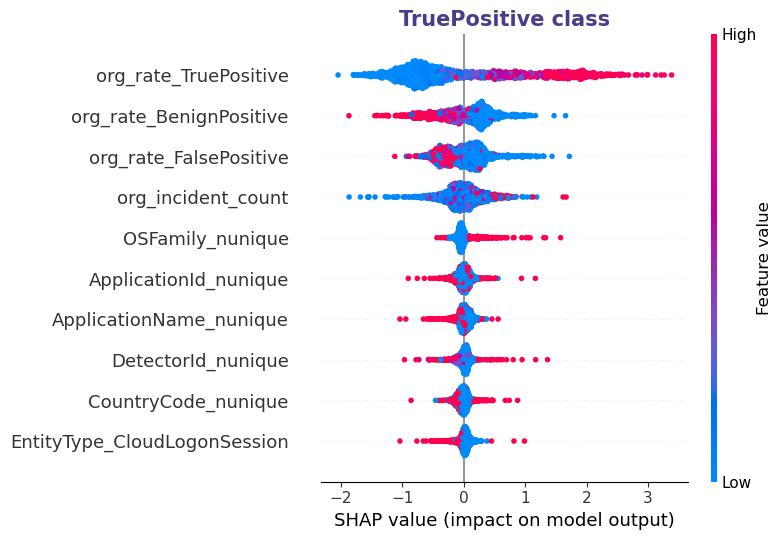

In [14]:
top_feat = 10

for cls, cls_name in enumerate(classes_names):
    top_idx = np.argsort(
        np.abs(shap_values[:, cls, :]).mean(axis=1)
    )[-top_feat:]
    top_feature_names = [feat_col[i] for i in top_idx]

    shap.summary_plot(
        shap_values[top_idx, cls, :].T,
        features = X_explain[:,top_idx],
        feature_names = top_feature_names,
        show = False,
    )
    plt.title(f"{cls_name} class", color=colors[cls], fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'artifacts/xai_beeswarm_{cls_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

the plots show that the computed org-level stats plays a big role in the output which mean that the model may do poorly at generalizing to new organizations 